# Exercise 2.11

In [2]:
import numpy as np
rng = np.random.default_rng(0)

In [3]:
class BanditNonstat:
    def __init__(self, k, noise_var, **kwargs):
        self.k = k
        self.noise_var = noise_var
        self.q = np.zeros(k)
        self.optimal_action = self.q.argmax()
        self.r_sigma = 1.0
    
    def _add_noise(self):
        self.q += rng.normal(0, self.noise_var)

    def step(self, k):
        self._add_noise()
        return rng.normal(self.q[k], self.r_sigma)

In [4]:
from dataclasses import dataclass
from typing import Any

@dataclass
class Config:
    bandit_cls: Any
    k: int
    time_steps: int
    experiments: int
    eps: float
    constant_step: bool
    alpha: float = None
    noise_var: float = None
    Q_init: float = 0.0

In [12]:
class MetricsSingle:
    def __init__(self):
        self.rewards = []

    def step(self, reward: float):
        self.rewards.append(reward)

    def average_reward(self, last_n=None):
        if last_n is None:
            return np.array(self.rewards).mean()
        return np.array(self.rewards[len(self.rewards) - last_n :]).mean()

class MetricsCollection:
    def __init__(self, base_c: Config, nr_configs: int):
        self.avg_rewards = np.zeros((base_c.experiments, nr_configs))
        self.last_n = 100000
        self.param_id_latex = "\epsilon"

    def save_experiment(self, ms: MetricsSingle, experiment_idx: int, config_idx: int):
        self.avg_rewards[experiment_idx, config_idx] = ms.average_reward(last_n=self.last_n)

    def get_average_rewards(self):
        return np.mean(self.avg_rewards, axis=0)

In [13]:
def do_experiment(c: Config):
    b = c.bandit_cls(k=c.k, noise_var=c.noise_var)
    Q = np.zeros(c.k) + c.Q_init
    N = np.zeros(c.k)

    def select_action():
        if c.eps > rng.random():
            return rng.integers(0, c.k)
        return Q.argmax()

    ms = MetricsSingle()
    step_size = (lambda: c.alpha) if c.constant_step else (lambda: 1 / N[A])
    for t in range(c.time_steps):
        A = select_action()
        R = b.step(A)
        N[A] += 1
        Q[A] = Q[A] + step_size() * (R - Q[A])
        ms.step(R)

    return ms

In [14]:
import matplotlib.pyplot as plt

def plot_param_study(metrics_list: list[MetricsCollection], param_lists: list[np.ndarray]):
    for mc, p in zip(metrics_list, param_lists):
        x = p
        y = mc.get_average_rewards()
        plt.plot(x, y, label=rf"${mc.param_id_latex}$")
    x_label = r"$" + " ".join([m.param_id_latex for m in metrics_list]) + r"$"
    plt.xlabel(x_label)
    plt.ylabel(f"Average reward over last {metrics_list[0].last_n} steps")
    plt.legend()
    plt.show()

In [33]:
import copy
eps_list = 1/128 * (2.0 ** np.arange(8))
configs = []
base_c = Config(
    bandit_cls = BanditNonstat,
    k = 10,
    time_steps = 200000,
    experiments = 100,
    eps = 0.0,
    constant_step = True,
    alpha = 0.1,
    noise_var = 0.01,
)
for i in range(eps_list.size):
    c = copy.deepcopy(base_c)
    c.eps = eps_list[i]
    configs.append(c)

metrics = []
mc = MetricsCollection(base_c, eps_list.size)
for i in range(base_c.experiments):
    for j, c in enumerate(configs):
        ms: MetricsSingle = do_experiment(c)
        mc.save_experiment(ms, i, j)
metrics.append(mc)

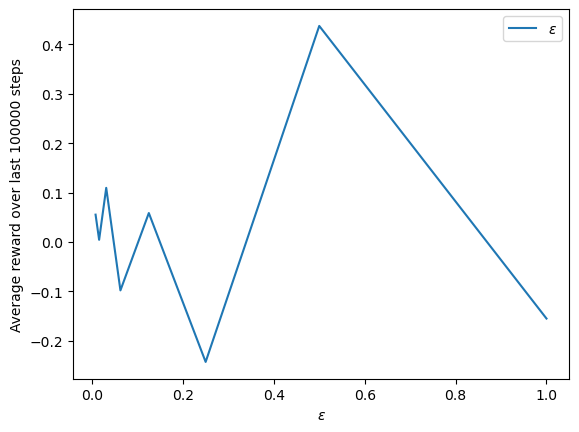

In [34]:
plot_param_study([mc], [eps_list])